# Deep Learning Approach for Neural Encoding of Musical Surprisal and Acoustic Features 


This notebook walks through a deep learning approach to neural encoding which models how the brain's EEG response tracks the acoustic and musical structure of a piece it's listening to. The model is a **nonlinear 1-D convolutional network** which configurations to increase the number of blocks, and replicate the approach using linear and separable methods. Additionally, we compare our model with the standard linear approach in literature implemented in three ways here: 
- Explicit ridge regression
- MNE's ReceptiveField, 
- eelbrain's boosting algorithm

To evaluate the models, we compare how well each predicts EEG recordings using two stimulus feature sets: low-level acoustic features (envelope, onsets) and a complete set that adds musical surprisal and entropy (derived via IDyOM from the score). All models are evaluated with the same leave-one-trial-out cross-validation, so results are directly comparable across model families.

The notebook is organized into three parts: 
1. **Data Preparation:** loading the TRFDataset and PreparedSubject classes which pre-processes raw EEG and time-aligns it with stimulus features as well as z-scores trial datasets for model consumption
2. **Running Models:** fitting each TRF variant and the CNN model, subject by subject using default configurations
3. **Examining Results:** loading the saved outputs, comparing predictive correlation across models and feature sets, and visualizing predicted-vs-actual EEG


## 1. Data Preparation

In [1]:
# Smoke test: PreparedSubject shared across both conditions for Sub2, plus
# full-trial mode + windowed mode, confirming no cross-condition aliasing.
from config import load_config
import utils
import pretty_midi
import yaml
import numpy as np
import pandas as pd
import torch

from dataset import PreparedSubject, TRFDataset

config = load_config()
subject = 'Sub2'
eeg_path = config.paths.eeg_dir / config.eeg_filename_pattern.format(subject=subject)
eeg_data = utils.load_subject_raw_eeg(eeg_path, subject)

prepared = PreparedSubject(subject, eeg_data, config, debug=True)

## ── both conditions share the same PreparedSubject (steps 1-6 run once) ──
ds_acoustic = prepared.to_dataset('acoustic', window_samples=None)
ds_full = prepared.to_dataset('acoustic_and_surprisal', window_samples=None)
# assert ds_acoustic.events is ds_full.events is prepared.events, \
    # "both conditions should share the same PreparedSubject.events object"
assert ds_acoustic.trials is not ds_full.trials
# 'acoustic' only z-scores 2 features; 'acoustic_and_surprisal' z-scores 6.
assert set(ds_acoustic.trials[0].keys()) == {'eeg', 'envelope', 'onsets'}
assert set(ds_full.trials[0].keys()) == {
    'eeg', 'envelope', 'onsets', 'pitch_surprisal', 'pitch_entropy',
    'onset_surprisal', 'onset_entropy'}
# calling to_dataset twice must not have mutated prepared._trials_raw in a
# way that cross-contaminates: envelope z-scored the same way in both.
assert np.allclose(ds_acoustic.trials[0]['envelope'], ds_full.trials[0]['envelope'])
print("[PreparedSubject] shared events, independent per-condition trials: OK")

assert len(ds_full) == len(ds_full.trial_lengths) == ds_full.n_trials
X0, Y0 = ds_full[0]
T0 = ds_full.trial_lengths[0]
assert X0.shape == (len(ds_full.feature_keys), T0), (X0.shape, T0)
assert Y0.shape == (ds_full.n_channels, T0), (Y0.shape, T0)
assert X0.dtype == torch.float32 and Y0.dtype == torch.float32
print(f"[full-trial] len(ds)={len(ds_full)} == n_trials, "
        f"ds[0] X{tuple(X0.shape)} Y{tuple(Y0.shape)} float32: OK")

# ── windowed mode, derived from the SAME prepared subject ──
ws, hs = 64, 64
ds_win = prepared.to_dataset('acoustic_and_surprisal', window_samples=ws, hop_samples=hs)
manual = sum(max(0, (T - ws) // hs + 1) for T in ds_win.trial_lengths)
assert len(ds_win) == manual == len(ds_win.window_trial_indices), (len(ds_win), manual)
Xw, Yw = ds_win[0]
assert Xw.shape == (len(ds_win.feature_keys), ws)
assert Yw.shape == (ds_win.n_channels, ws)
assert Xw.dtype == torch.float32 and Yw.dtype == torch.float32
for ti in range(ds_win.n_trials):
    idxs = ds_win.windows_for_trial(ti)
    assert all(ds_win.window_trial_indices[j] == ti for j in idxs)
total = sum(len(ds_win.windows_for_trial(ti)) for ti in range(ds_win.n_trials))
assert total == len(ds_win)
print(f"[windowed]  len(ds)={len(ds_win)} == manual window count, "
        f"ds[0] X{tuple(Xw.shape)} Y{tuple(Yw.shape)} float32, "
        f"windows_for_trial consistent: OK")

# ── TRFDataset's direct constructor still works (builds its own throwaway
# PreparedSubject internally) ──
ds_direct = TRFDataset(subject, eeg_data, 'acoustic', config, window_samples=int(2.0*64))
assert np.allclose(ds_direct.trials[0]['eeg'], ds_acoustic.trials[0]['eeg'])
print("[direct constructor] TRFDataset(...) still works standalone: OK")

print("SMOKE TEST PASSED")


✓ Loaded raw EEG (Sub2): 30 trials, 64 channels @ 512 Hz
  [pre] Trial 1: raw = 82395 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 1: post-preproc = 10236 samples @ 64 Hz
  [pre] Trial 2: raw = 79891 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 2: post-preproc = 9923 samples @ 64 Hz
  [pre] Trial 3: raw = 62544 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 3: post-preproc = 7754 samples @ 64 Hz
  [pre] Trial 4: raw = 70553 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 4: post-preproc = 8756 samples @ 64 Hz
  [pre] Trial 5: raw = 85879 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 5: post-preproc = 10671 samples @ 64 Hz
  [pre] Trial 6: raw = 103070 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 6: post-preproc = 12820 samples @ 64 Hz
  [pre] Trial 7: raw = 89690 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 7: post-preproc = 11148 samples @ 64 Hz
  [pre] Trial 8: raw = 94316 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 8: post-preproc =

/Users/arianapereira/miniconda3/envs/eelbrain-env/lib/python3.11/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


[PreparedSubject] shared events, independent per-condition trials: OK
[full-trial] len(ds)=30 == n_trials, ds[0] X(6, 10172) Y(64, 10172) float32: OK
[windowed]  len(ds)=4794 == manual window count, ds[0] X(6, 64) Y(64, 64) float32, windows_for_trial consistent: OK
[direct constructor] TRFDataset(...) still works standalone: OK
SMOKE TEST PASSED


Columns in the trials_raw list: dict_keys(['eeg', 'envelope', 'onsets', 'pitch_surprisal', 'pitch_entropy', 'onset_surprisal', 'onset_entropy'])
Number of trials for each subject: 30
Number of samples in the first trial: 10172
Number of channels for each sample: 64


Text(0.5, 1.0, 'Raw EEG of Sub2 and Trial 1')

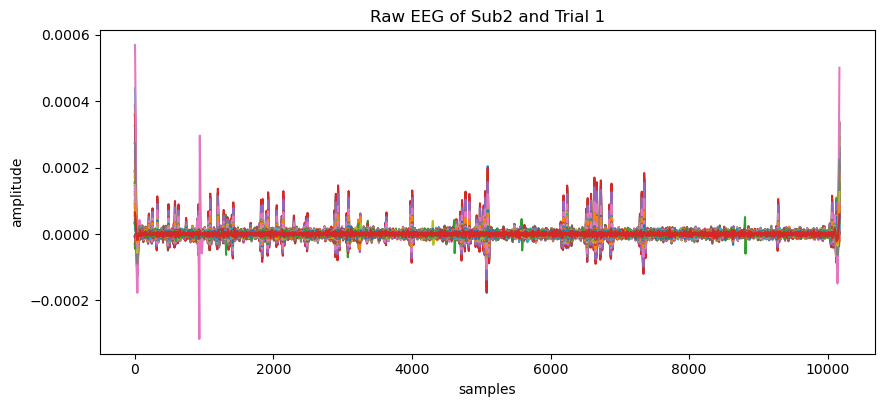

In [2]:
import matplotlib.pyplot as plt

ex_trial = 0 

print(prepared)
print("Columns in the trials_raw list:", prepared._trials_raw[0].keys())
print("Number of trials for each subject:",len(prepared._trials_raw))
print("Number of samples in the first trial:",len(prepared._trials_raw[ex_trial]['eeg']))
print("Number of channels for each sample:",len(prepared._trials_raw[ex_trial]['eeg'][0]))

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(prepared._trials_raw[0]['eeg'])
ax.set_xlabel('samples')
ax.set_ylabel('amplitude')
ax.set_title(f"Raw EEG of {subject} and Trial {ex_trial+1}")


In [3]:
print("Understanding the shapes and data contained in ds_full", ds_full)
print("Columns in the events table:", ds_full.events[0].keys())
print("Columns in the trials list:", ds_full.trials[0].keys())
print("Number of trials for each subject:",len(ds_full.trials))
print("Number of samples in the first trial:",len((ds_full.trials[0]['eeg'])))
print("Number of channels for each sample:",len((ds_full.trials[0]['eeg'][0])))
ds_full.events


Understanding the shapes and data contained in ds_full <dataset.TRFDataset object at 0x31afd1250>
Columns in the events table: dict_keys(['i_start', 'trigger', 'event', 'envelope', 'onsets', 'duration', 'eeg', 'pitch_surprisal', 'pitch_entropy', 'onset_surprisal', 'onset_entropy'])
Columns in the trials list: dict_keys(['eeg', 'envelope', 'onsets', 'pitch_surprisal', 'pitch_entropy', 'onset_surprisal', 'onset_entropy'])
Number of trials for each subject: 30
Number of samples in the first trial: 10172
Number of channels for each sample: 64


#,i_start,trigger,event,envelope,onsets,duration,eeg,pitch_surprisal,pitch_entropy,onset_surprisal,onset_entropy
0,1,1,1,<NDVar: 1017...,<NDVar: 1017...,158.94,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
1,10236,2,2,<NDVar: 9859...,<NDVar: 9859...,154.05,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
2,20159,3,3,<NDVar: 7690...,<NDVar: 7690...,120.16,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
3,27913,4,4,<NDVar: 8692...,<NDVar: 8692...,135.81,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
4,36669,5,5,<NDVar: 1060...,<NDVar: 1060...,165.73,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
5,47340,6,6,<NDVar: 1275...,<NDVar: 1275...,199.31,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
6,60160,7,7,<NDVar: 1108...,<NDVar: 1108...,173.19,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
7,71308,8,8,<NDVar: 1166...,<NDVar: 1166...,182.22,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
8,83034,9,9,<NDVar: 8588...,<NDVar: 8588...,134.19,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
9,91686,10,10,<NDVar: 1139...,<NDVar: 1139...,178.11,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...


Text(0.5, 1.0, 'Z-scored EEG of Sub2 and Trial 1')

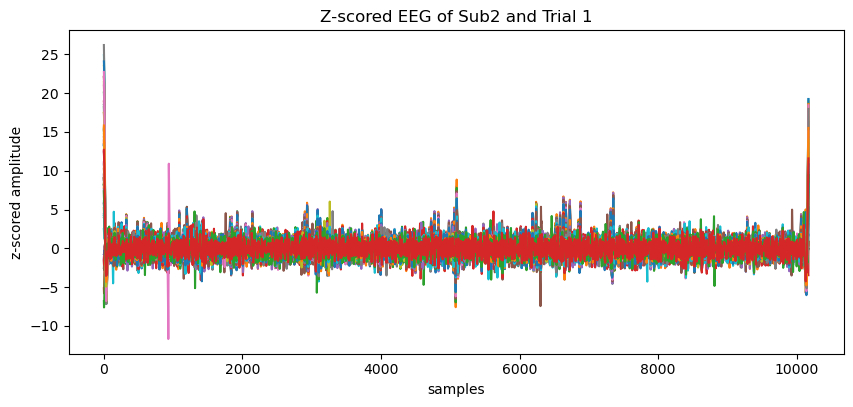

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(ds_full.trials[0]['eeg'])
ax.set_xlabel('samples')
ax.set_ylabel('z-scored amplitude')
ax.set_title(f"Z-scored EEG of {subject} and Trial {ex_trial+1}")


In [5]:
ds_direct = TRFDataset(
    subject, 
    eeg_data, 
    'acoustic', 
    config, 
    window_samples=7*64, 
    hop_samples=6*64
    ) 

In [6]:
print(len(ds_direct))
print(ds_direct.feature_set)


783
acoustic


In [7]:
config = load_config()
subject = 'Sub2'
eeg_path = config.paths.eeg_dir / config.eeg_filename_pattern.format(subject=subject)
eeg_data = utils.load_subject_raw_eeg(eeg_path, subject)

acoustic_ds = TRFDataset(
    subject, 
    eeg_data, 
    'acoustic',
    config, 
    window_samples=7*64,
    hop_samples=6*64
    )

acoustic_and_surprisal_ds = TRFDataset(
    subject, 
    eeg_data, 
    'acoustic_and_surprisal',
    config, 
    window_samples=7*64,
    hop_samples=6*64
    )

✓ Loaded raw EEG (Sub2): 30 trials, 64 channels @ 512 Hz


## 2. Running the Models

The results will be saved in the folder 'results' with .pkl files as well as .png visuals similar to those included below but some additional as well worth exploring like training and val loss across epochs 

In [8]:
## Make sure your environment is set up (conda activate eelbrain-env and source musical-surprisal/TRF/.venv/bin/activate)
## In order to run the 3 baseline TRF models and the nonlinear variant of the convolutional network model, run:
#! python run_all_models.py

## Next, to run the linear and separable model variants of the convolutional network, go to 'TRF_conv.py' and 
## change the model variant from 'nonlinear' to 'linear', or 'separable'. Then go to 'run_all_models.py' and comment out the 3 TRF models 
## so only the TRF_conv.py script will run



# Examine Experiment Results

First we inspect what the contents of the produced .pkl files are by using the sklearn_ridge file as an example. Then we define some plotting functions and examine the results saved in `baselines` results folder

In [25]:
import pickle
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import eelbrain
from eelbrain import combine


In [26]:
sklearn_data_acoustic = eelbrain.load.unpickle(f"results/baselines/Sub1__sklearn_ridge__acoustic.pkl")
sklearn_data_acoustic.keys()

dict_keys(['meta', 'r_per_channel', 'per_trial_r', 'Y_pred', 'Y_true', 'weights', 'alpha_selection', 'training_history'])

In [27]:
print("\nResults")
print("-"*64)

print("per_trial_r shape:", sklearn_data_acoustic['per_trial_r'].shape, "= (n_trials, n_channels)")
print("r_per_channel type:", type(sklearn_data_acoustic['r_per_channel']), "and shape:", sklearn_data_acoustic['r_per_channel'].shape)
# r_per_channel is the pearson's correlation over all the trials concatenated (for every channel = pearsonr(Y_true, Y_pred))
# per_trial_r is the pearson's correlation computed per trial and per channel 

print("Y_pred shape:", sklearn_data_acoustic['Y_pred'].shape, "= (n_samples, n_channels)")
print("Y_true shape:", sklearn_data_acoustic['Y_true'].shape, "= (n_samples, n_channels)")
# 307527 is the total number of samples which are when actual EEG is being recorded. 
# There is a buffer 1 second (64 samples) in between each trial which is why the total sample_id is higher 

print("\nModel Dependent Results")
print("-"*64)
print("weights shape:", sklearn_data_acoustic['weights'].shape, "= (n_channels, n_lags, n_features)")
print("alpha_selection type:", type(sklearn_data_acoustic['alpha_selection']), " Ridge model only {alpha: mean_cv_r}")
print("training_history type:", type(sklearn_data_acoustic['training_history']), "Conv model only dict of per-epoch arrays")


Results
----------------------------------------------------------------
per_trial_r shape: (30, 64) = (n_trials, n_channels)
r_per_channel type: <class 'numpy.ndarray'> and shape: (64,)
Y_pred shape: (307527, 64) = (n_samples, n_channels)
Y_true shape: (307527, 64) = (n_samples, n_channels)

Model Dependent Results
----------------------------------------------------------------
weights shape: (64, 46, 2) = (n_channels, n_lags, n_features)
alpha_selection type: <class 'dict'>  Ridge model only {alpha: mean_cv_r}
training_history type: <class 'NoneType'> Conv model only dict of per-epoch arrays


In [28]:
def permutation_test(a, b, n_permutations=10000, two_tailed=True, seed=42):
    """Sign-flip permutation test for paired data."""
    rng = np.random.default_rng(seed)
    diff = b - a
    observed = diff.mean()
    
    count = 0
    for _ in range(n_permutations):
        signs = rng.choice([-1, 1], size=len(diff))
        perm_mean = (signs * diff).mean()
        if two_tailed:
            count += abs(perm_mean) >= abs(observed)
        else:
            count += perm_mean >= observed
    
    p_val = count / n_permutations
    return observed, p_val

In [ ]:
def plot_model_comparison(models=None, n_subjects=None, pickle_folder=None):
    """
    Create a single figure showing side-by-side violins of mean CV correlation
    (acoustic vs full) for multiple models. Prints a p-value / mean-diff table
    below the plot.
    """
    if n_subjects is None:
        n_subjects = globals().get('n_subjects', 20)
    if pickle_folder is None:
        pickle_folder = globals().get('pickle_folder', 'baselines')
    if models is None:
        models = ['boosting', 'sklearn_ridge', 'mne_ridge', 'conv_nonlinear','conv_linear','conv_separable' ]

    colors = ['steelblue', 'darkorange']
    fig, ax = plt.subplots(figsize=(12, 6))

    spacing = 3
    centers = []
    legend_handles = [
        Patch(facecolor=colors[0], edgecolor='none', label='Acoustic (envelope + onsets)'),
        Patch(facecolor=colors[1], edgecolor='none', label='Full (+ surprisal + entropy)')
    ]

    stats_rows = []
    
    for i, model_name in enumerate(models):
        r_acoustic_all = []
        r_full_all = []

        for sub in range(1, n_subjects + 1):
            try:
                a = eelbrain.load.unpickle(f"results/{pickle_folder}/Sub{sub}__{model_name}__acoustic.pkl")
                f = eelbrain.load.unpickle(f"results/{pickle_folder}/Sub{sub}__{model_name}__acoustic_and_surprisal.pkl")
                r_acoustic_all.append(a['r_per_channel'])
                r_full_all.append(f['r_per_channel'])
            except FileNotFoundError:
                # skip missing subjects for this model
                continue

        if len(r_acoustic_all) == 0:
            continue

        r_acoustic_all = np.array(r_acoustic_all)
        r_full_all = np.array(r_full_all)
        r_acoustic_per_sub = r_acoustic_all.mean(axis=1)
        r_full_per_sub = r_full_all.mean(axis=1)

        base = i * spacing
        pos = [base + 1, base + 2]
        centers.append((pos[0] + pos[1]) / 2)

        parts = ax.violinplot([r_acoustic_per_sub, r_full_per_sub],
                              positions=pos, showmedians=False, showextrema=False)
        for pc, color in zip(parts['bodies'], colors):
            pc.set_facecolor(color)
            pc.set_alpha(0.6)

        # connect paired subject points within this model
        for j in range(len(r_acoustic_per_sub)):
            ax.plot([pos[0], pos[1]],
                    [r_acoustic_per_sub[j], r_full_per_sub[j]],
                    color='gray', alpha=0.4, linewidth=0.7)

        # scatter with jitter
        jitter = np.random.uniform(-0.04, 0.04, size=len(r_acoustic_per_sub))
        ax.scatter(np.full(len(r_acoustic_per_sub), pos[0]) + jitter, r_acoustic_per_sub,
                   color=colors[0], edgecolors='white', linewidths=0.5, s=40, alpha=0.8, zorder=4)
        jitter = np.random.uniform(-0.04, 0.04, size=len(r_full_per_sub))
        ax.scatter(np.full(len(r_full_per_sub), pos[1]) + jitter, r_full_per_sub,
                   color=colors[1], edgecolors='white', linewidths=0.5, s=40, alpha=0.8, zorder=4)

        # mean ± SEM markers
        for k, d in enumerate([r_acoustic_per_sub, r_full_per_sub], start=0):
            mean_val = d.mean()
            sem = d.std() / np.sqrt(len(d))
            ax.errorbar(pos[k], mean_val, yerr=sem, fmt='o', color='black',
                        markersize=6, capsize=4, linewidth=1.5, zorder=5)

        # optional: compute and display p-value for this model
        try:
            mean_diff, p_val = permutation_test(r_acoustic_per_sub, r_full_per_sub,
                                                n_permutations=10000, two_tailed=True)
            sig_label = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
            y_bracket = max(r_acoustic_per_sub.max(), r_full_per_sub.max()) + 0.005
            stats_rows.append({'model': model_name, 'p_val': p_val, 'mean_diff': mean_diff})
            ax.plot([pos[0], pos[0], pos[1], pos[1]],
                    [y_bracket - 0.003, y_bracket, y_bracket, y_bracket - 0.003],
                    color='black', linewidth=1.0)
            ax.text((pos[0] + pos[1]) / 2, y_bracket + 0.003, f'p={p_val:.3f} {sig_label}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        except Exception:
            pass

    ax.set_xticks(centers)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_xlim(-0.5, spacing * len(models) - 0.5)
    ax.set_ylabel('Mean CV Correlation (r)', fontsize=12)
    ax.set_title(f'Comparison across models', fontsize=13)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

    ax.legend(handles=legend_handles, loc='upper left')
    plt.tight_layout()
    plt.show()

    stats_df = pd.DataFrame(stats_rows)  
    display(stats_df)

In [45]:
def plot_model_results(model, n_subjects=None, pickle_folder=None):
    """
    Create a violin plot of the mean CV correlation for the specified model and 
    evaluate the statistical significance of adding surprisal features (acoustic vs full).
    
    Additionally, plot the per-subject mean r (averaged across channels)
    """
    
    if n_subjects is None:
        n_subjects = globals().get('n_subjects', 20)
    if pickle_folder is None:
            pickle_folder = globals().get('pickle_folder', 'baselines')
    
    # ── 1. Load all subjects ──────────────────────────────────────────────────────
    n_subjects = n_subjects
    r_acoustic_all = []  # will be shape (n_subjects, n_channels)
    r_full_all     = []

    print("="*64)
    print(f'Loading {model} Results')
    print("="*64)
    for sub in range(1, n_subjects + 1):
        try:
            data_acoustic = eelbrain.load.unpickle(f"results/{pickle_folder}/Sub{sub}__{model}__acoustic.pkl")
            data_full     = eelbrain.load.unpickle(f"results/{pickle_folder}/Sub{sub}__{model}__acoustic_and_surprisal.pkl")

            r_acoustic_all.append(data_acoustic['r_per_channel'])
            r_full_all.append(data_full['r_per_channel'])
            print(f"  Sub{sub:02d} loaded")

        except FileNotFoundError:
            print(f"  Sub{sub:02d} missing — skipping")

    r_acoustic_all = np.array(r_acoustic_all)  # (n_subjects, n_channels)
    r_full_all     = np.array(r_full_all)
    n_subjects     = len(r_acoustic_all)       # update in case any were skipped

    print(f"\nLoaded {n_subjects} subjects, {r_acoustic_all.shape[1]} channels each")

    # ── 2. Per-subject mean r (averaged across channels) ─────────────────────────
    r_acoustic_per_sub = r_acoustic_all.mean(axis=1)  # (n_subjects,)
    r_full_per_sub     = r_full_all.mean(axis=1)
    r_diff_per_sub     = r_full_per_sub - r_acoustic_per_sub

    # ── 3. Group-level statistics — two-tailed sign-flip permutation test ─────────
    mean_diff, p_val = permutation_test(r_acoustic_per_sub, r_full_per_sub,
                                        n_permutations=10000, two_tailed=True)
    sem_diff = r_diff_per_sub.std() / np.sqrt(n_subjects)

    # Per-channel permutation test across subjects + FDR correction
    n_channels    = r_acoustic_all.shape[1]
    p_per_channel = np.array([
        permutation_test(r_acoustic_all[:, ch], r_full_all[:, ch],
                        n_permutations=10000, two_tailed=True)[1]
        for ch in range(n_channels)
    ])
    _, p_fdr = fdrcorrection(p_per_channel)

    sig_label = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    print(f"\nGroup-level permutation test (mean r across channels):")
    print(f"  p = {p_val:.4f}  {sig_label}")
    print(f"  Mean Δr = {mean_diff:.4f} ± {sem_diff:.4f} SEM")
    print(f"  Channels significant after FDR (p<0.05): {(p_fdr < 0.05).sum()} / {n_channels}")


    # ── 4. Figure 1 – Violin: group-level acoustic vs full ───────────────────────
    fig, ax = plt.subplots(figsize=(7, 6))

    data   = [r_acoustic_per_sub, r_full_per_sub]
    labels = ['Acoustic\n(envelope + onsets )', 'Full\n(+ surprisal + entropy)']
    colors = ['steelblue', 'darkorange']

    parts = ax.violinplot(data, positions=[1, 2], showmedians=False, showextrema=False)
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)

    # Individual subject points connected by lines
    for i in range(n_subjects):
        ax.plot([1, 2], [r_acoustic_per_sub[i], r_full_per_sub[i]],
                color='gray', alpha=0.4, linewidth=0.8)
        # ax.text(1-0.08,r_acoustic_per_sub[i], f'{r_acoustic_per_sub[i]:.4f}', 
        #         fontsize=8, va='center', ha='right', alpha=0.7)
        # ax.text(2 + 0.08, r_full_per_sub[i], f'{r_full_per_sub[i]:.4f}', 
        #         fontsize=8, va='center', ha='left', alpha=0.7)
        
    for i, (d, color) in enumerate(zip(data, colors), start=1):
        jitter = np.random.uniform(-0.04, 0.04, size=len(d))
        ax.scatter(i + jitter, d, color=color, s=40, alpha=0.8,
                edgecolors='white', linewidths=0.5, zorder=4)

    # Mean ± SEM
    for i, d in enumerate(data, start=1):
        mean_val = d.mean()
        
        ax.errorbar(i, mean_val, yerr=d.std() / np.sqrt(len(d)),
                    fmt='o', color='black', markersize=7, capsize=5, linewidth=2, zorder=5)
        ax.text(i + 0.08, mean_val, f'Mean: {mean_val:.4f}', 
                color='black', fontsize=10, fontweight='bold', va='center', ha='left', zorder=6)

    # Significance bracket
    y_bracket = max(r_acoustic_per_sub.max(), r_full_per_sub.max()) + 0.005
    ax.plot([1, 1, 2, 2], [y_bracket - 0.003, y_bracket, y_bracket, y_bracket - 0.003],
            color='black', linewidth=1.2)
    ax.text(1.5, y_bracket + 0.003, f'p = {p_val:.4f}  {sig_label}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel('Mean CV Correlation (r)', fontsize=12)
    ax.set_title(f'{model} Encoding Correlation\n(N = {n_subjects} subjects)', fontsize=13)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlim(0.4, 2.6)
    plt.tight_layout()
    # plt.savefig('group_violin.png', dpi=150)
    plt.show()

    # ── 5. Figure 2 – Per-subject Δr bar chart ───────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 4))
    sub_labels = [f'Sub{i+1:02d}' for i in range(n_subjects)]
    colors_bar = ['seagreen' if d > 0 else 'crimson' for d in r_diff_per_sub]

    ax.bar(range(n_subjects), r_diff_per_sub, color=colors_bar, alpha=0.8, edgecolor='white')
    ax.axhline(0,         color='gray',  linewidth=0.8)
    ax.axhline(mean_diff, color='black', linewidth=1.5, linestyle='--',
            label=f'Group mean Δr = {mean_diff:.4f}')
    ax.set_xticks(range(n_subjects))
    ax.set_xticklabels(sub_labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Δr (full − acoustic)')
    ax.set_title(f'{model} Per-Subject Improvement from Adding Surprisal + Entropy\n(green = improvement, red = worse)')
    ax.legend()
    plt.tight_layout()
    # plt.savefig('group_delta_r_per_subject.png', dpi=150)
    plt.show()

    # ── 6. Figure 3 – Per-channel group Δr with FDR-corrected significance ───────
    r_diff_per_channel = (r_full_all - r_acoustic_all).mean(axis=0)  # (n_channels,)
    channel_names      = data_full['meta']['channel_names']

    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

    # Top: mean Δr per channel
    colors_ch = ['seagreen' if d > 0 else 'crimson' for d in r_diff_per_channel]
    axes[0].bar(range(n_channels), r_diff_per_channel, color=colors_ch, alpha=0.8, edgecolor='white')
    axes[0].axhline(0, color='gray', linewidth=0.8)
    axes[0].axhline(r_diff_per_channel.mean(), color='black', linestyle='--', linewidth=1.2,
                    label=f'Mean = {r_diff_per_channel.mean():.4f}')
    axes[0].set_ylabel('Mean Δr across subjects')
    axes[0].set_title(f'{model} Per-Channel Group Δr (full − acoustic)')
    axes[0].legend()

    # Bottom: -log10(p_fdr) per channel with significance threshold line
    neg_log_p_fdr = -np.log10(np.maximum(p_fdr, 1e-10))
    axes[1].bar(range(n_channels), neg_log_p_fdr, color='mediumpurple', alpha=0.8, edgecolor='white')
    axes[1].axhline(-np.log10(0.05), color='red',    linestyle='--', linewidth=1.2, label='FDR p = 0.05')
    axes[1].axhline(-np.log10(0.01), color='orange', linestyle='--', linewidth=1.2, label='FDR p = 0.01')
    axes[1].set_ylabel('−log₁₀(p_FDR)')
    axes[1].set_title(f'{model} Per-Channel Significance of Improvement (FDR-corrected permutation test)')
    axes[1].set_xticks(range(n_channels))
    axes[1].set_xticklabels(channel_names, rotation=90, fontsize=7)
    axes[1].legend()

    plt.tight_layout()
    # plt.savefig('group_per_channel.png', dpi=150)
    plt.show()

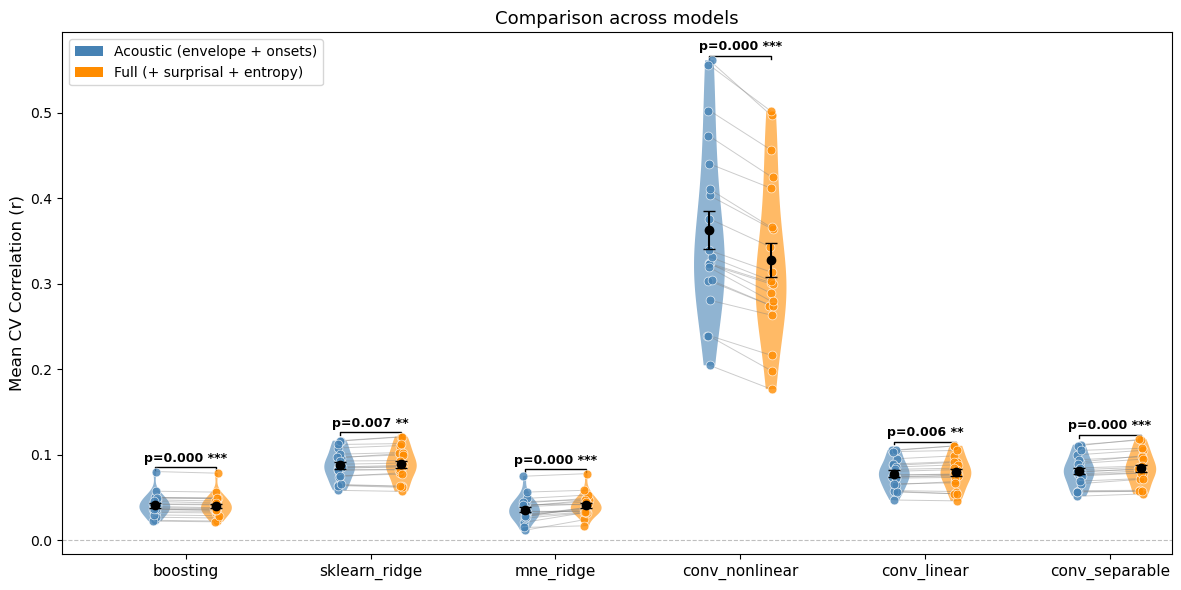

,model,p_val,mean_diff
0,boosting,0.0000,-0.000940
1,sklearn_ridge,0.0074,0.001471
2,mne_ridge,0.0000,0.004932
3,conv_nonlinear,0.0000,-0.034899
4,conv_linear,0.0064,0.001537
5,conv_separable,0.0000,0.003389


In [52]:
# Compare the mean correlation values per model when evaluated across all 20 subjects
plot_model_comparison()

Loading boosting Results
  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.0000  ***
  Mean Δr = -0.0009 ± 0.0001 SEM
  Channels significant after FDR (p<0.05): 50 / 64


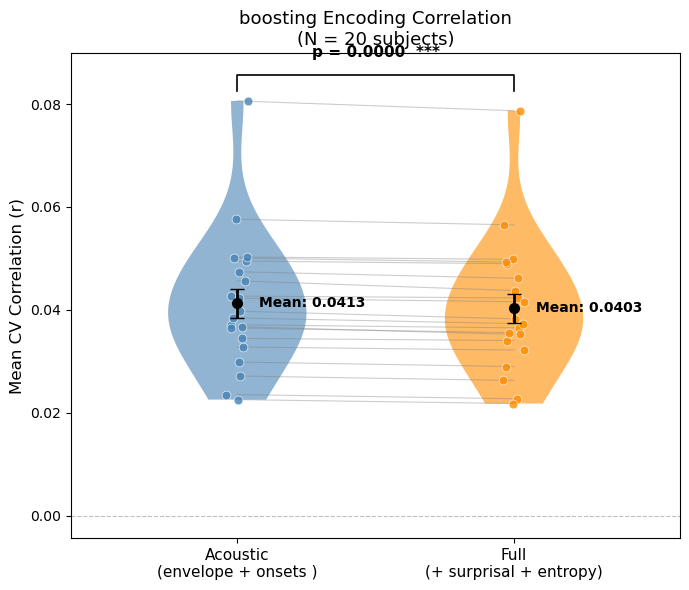

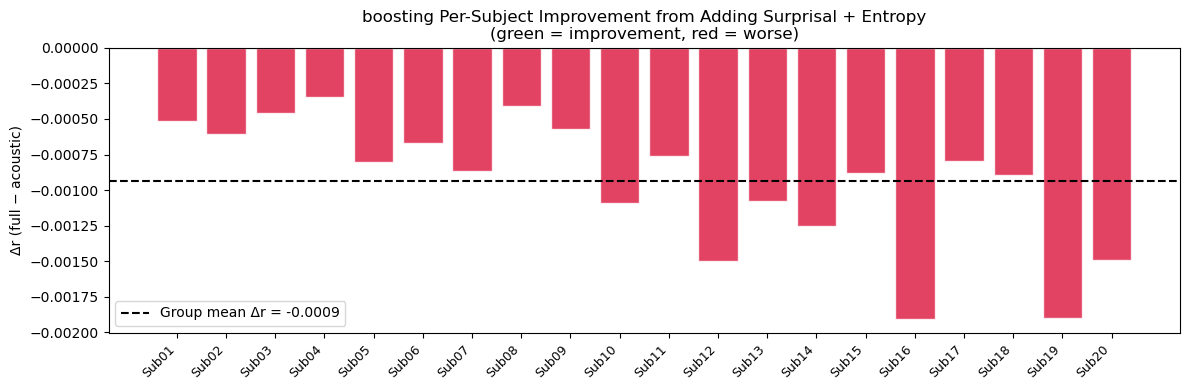

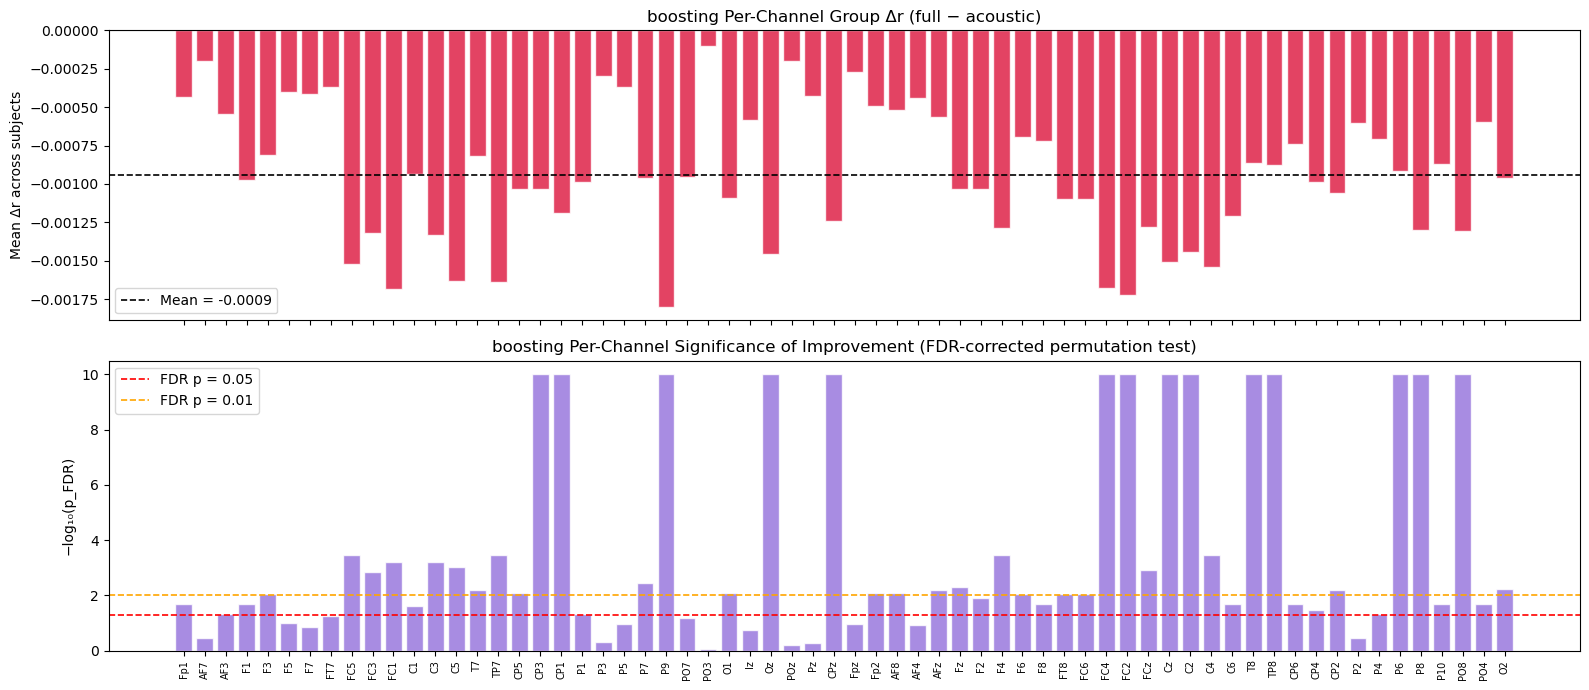

Loading sklearn_ridge Results
  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.0074  **
  Mean Δr = 0.0015 ± 0.0005 SEM
  Channels significant after FDR (p<0.05): 14 / 64


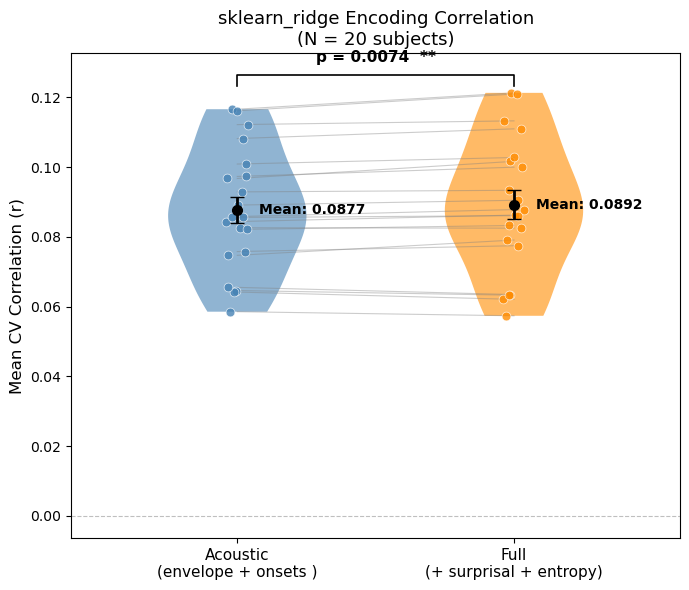

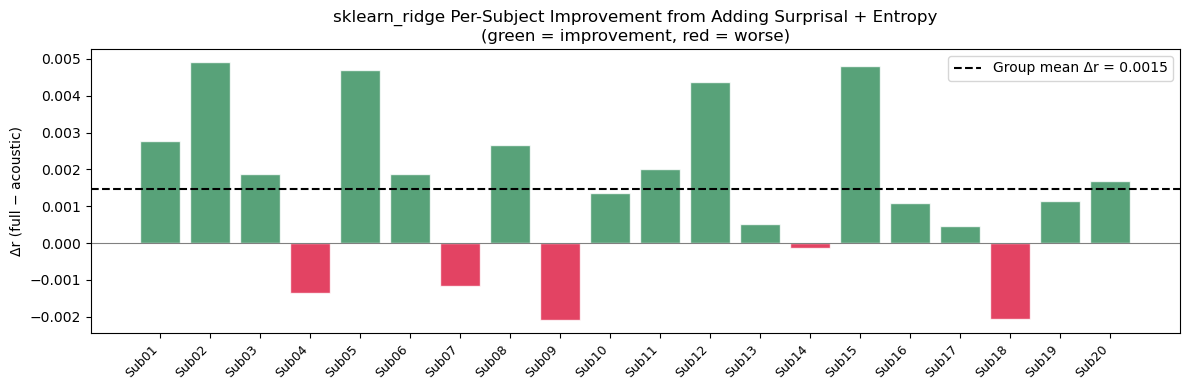

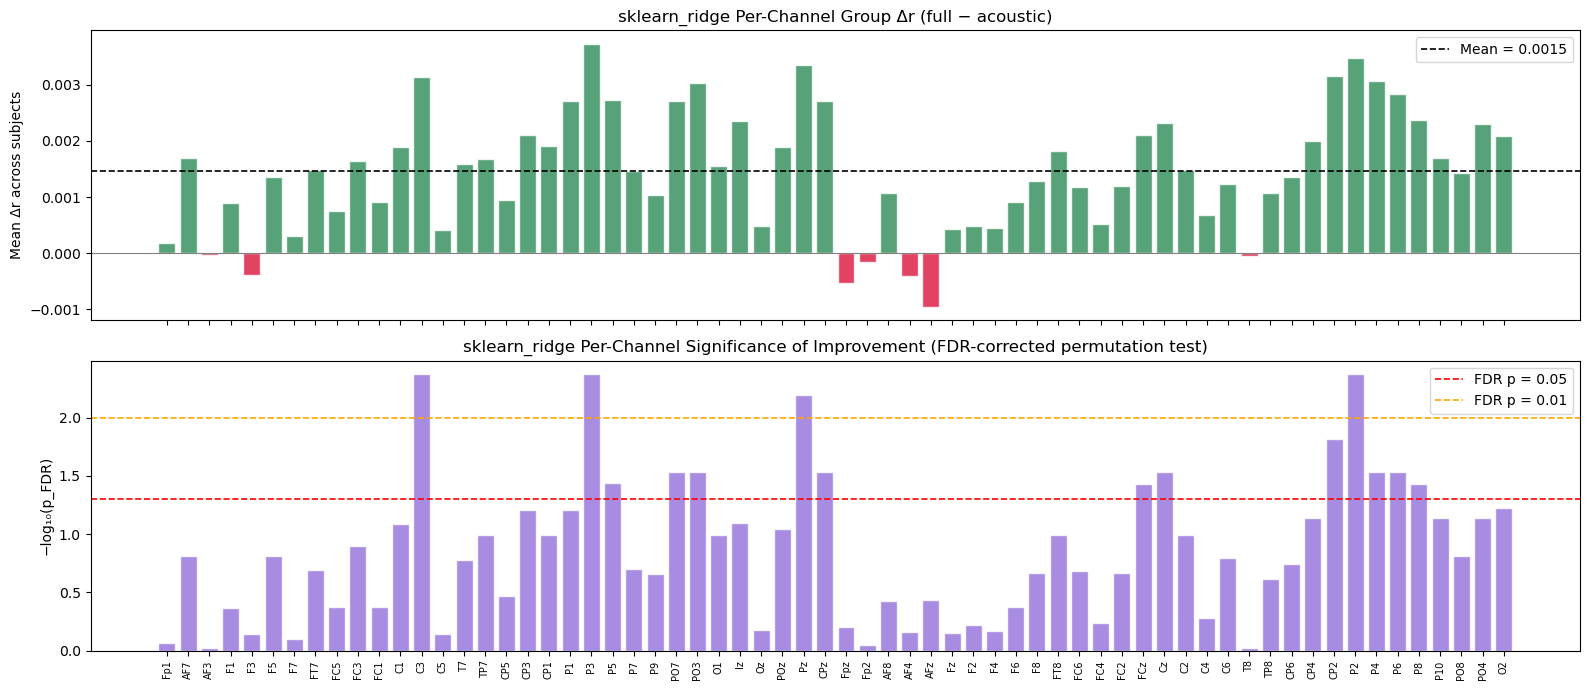

Loading mne_ridge Results
  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.0000  ***
  Mean Δr = 0.0049 ± 0.0008 SEM
  Channels significant after FDR (p<0.05): 56 / 64


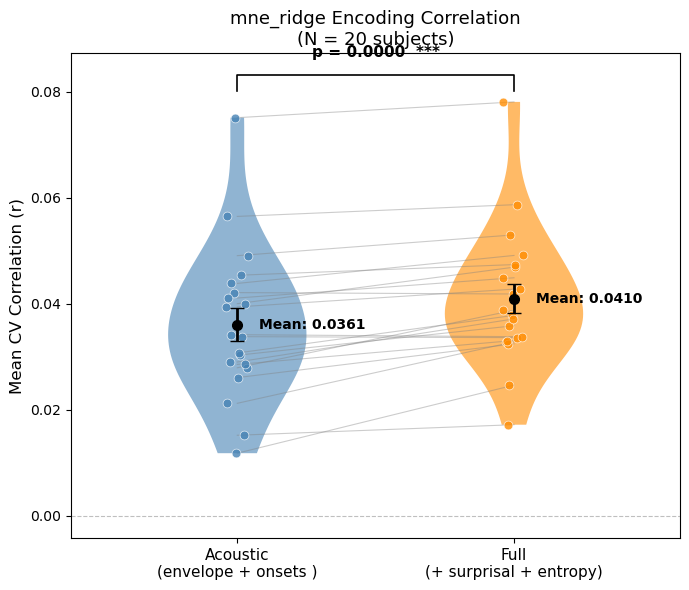

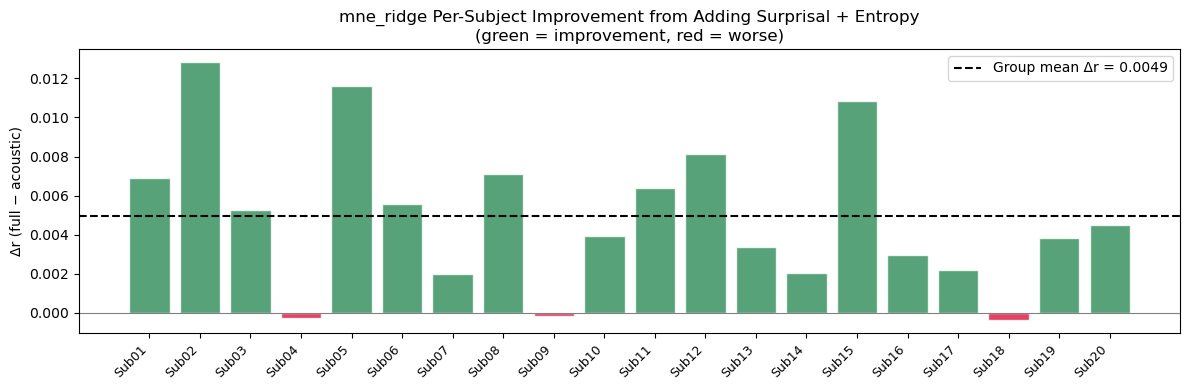

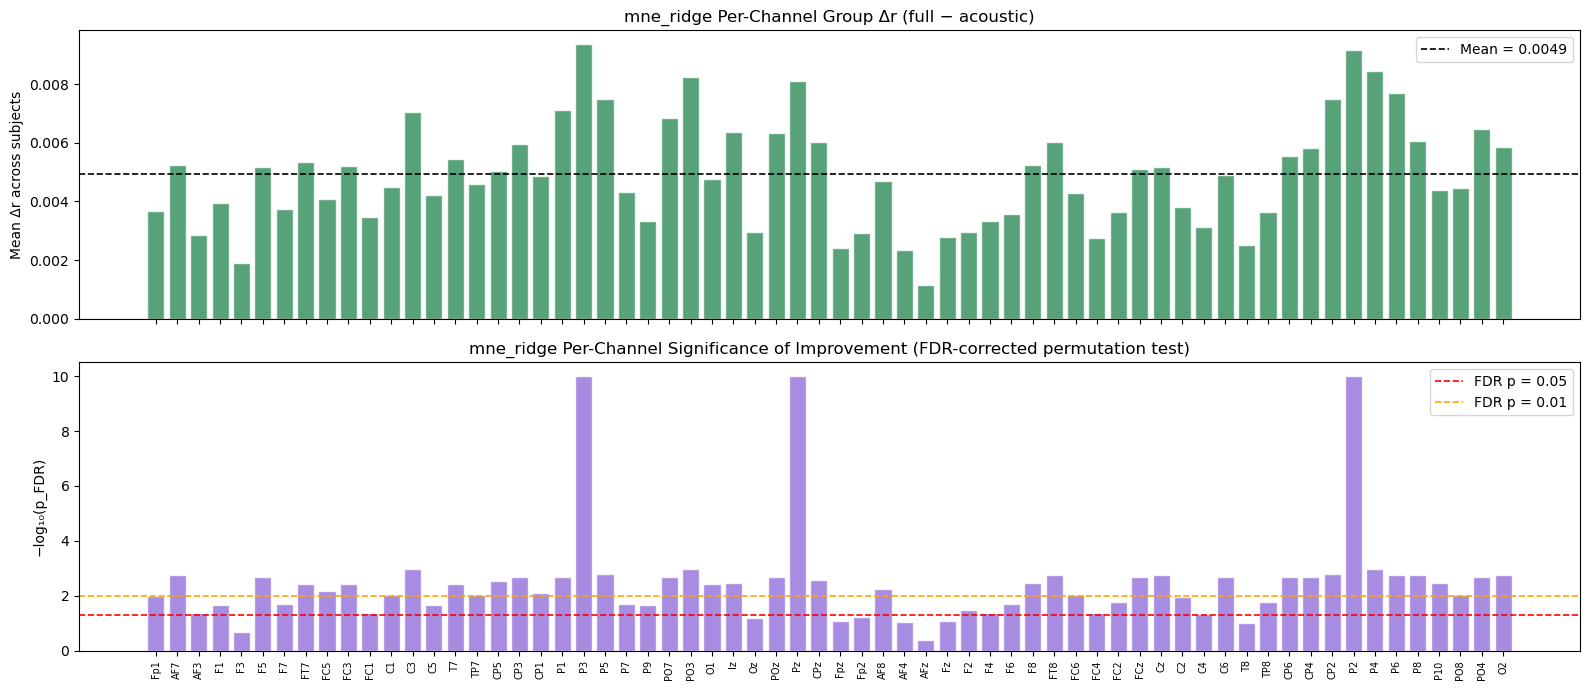

Loading conv_nonlinear Results
  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.0000  ***
  Mean Δr = -0.0349 ± 0.0026 SEM
  Channels significant after FDR (p<0.05): 64 / 64


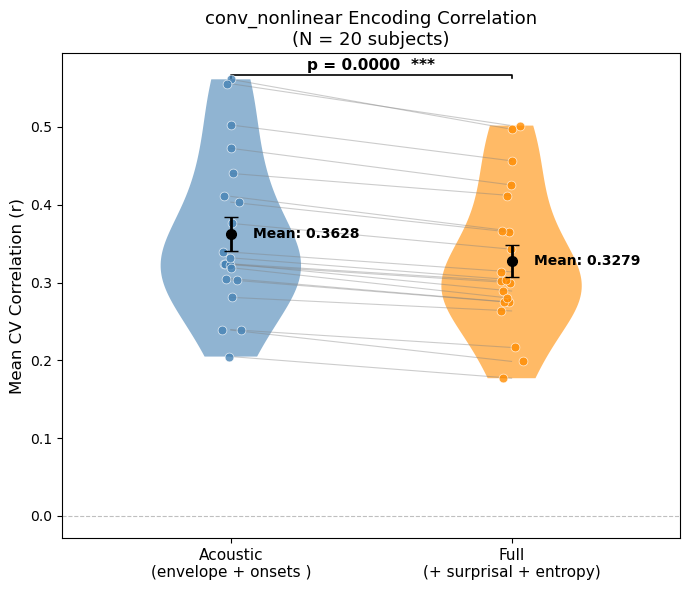

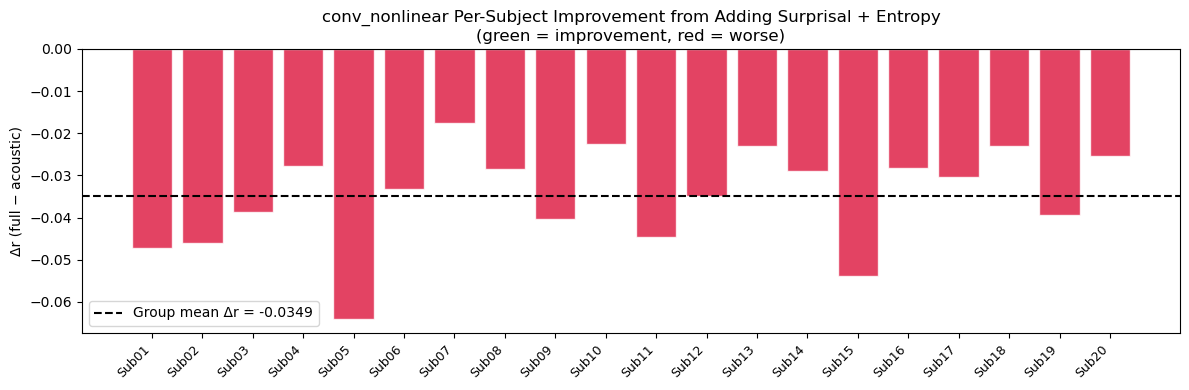

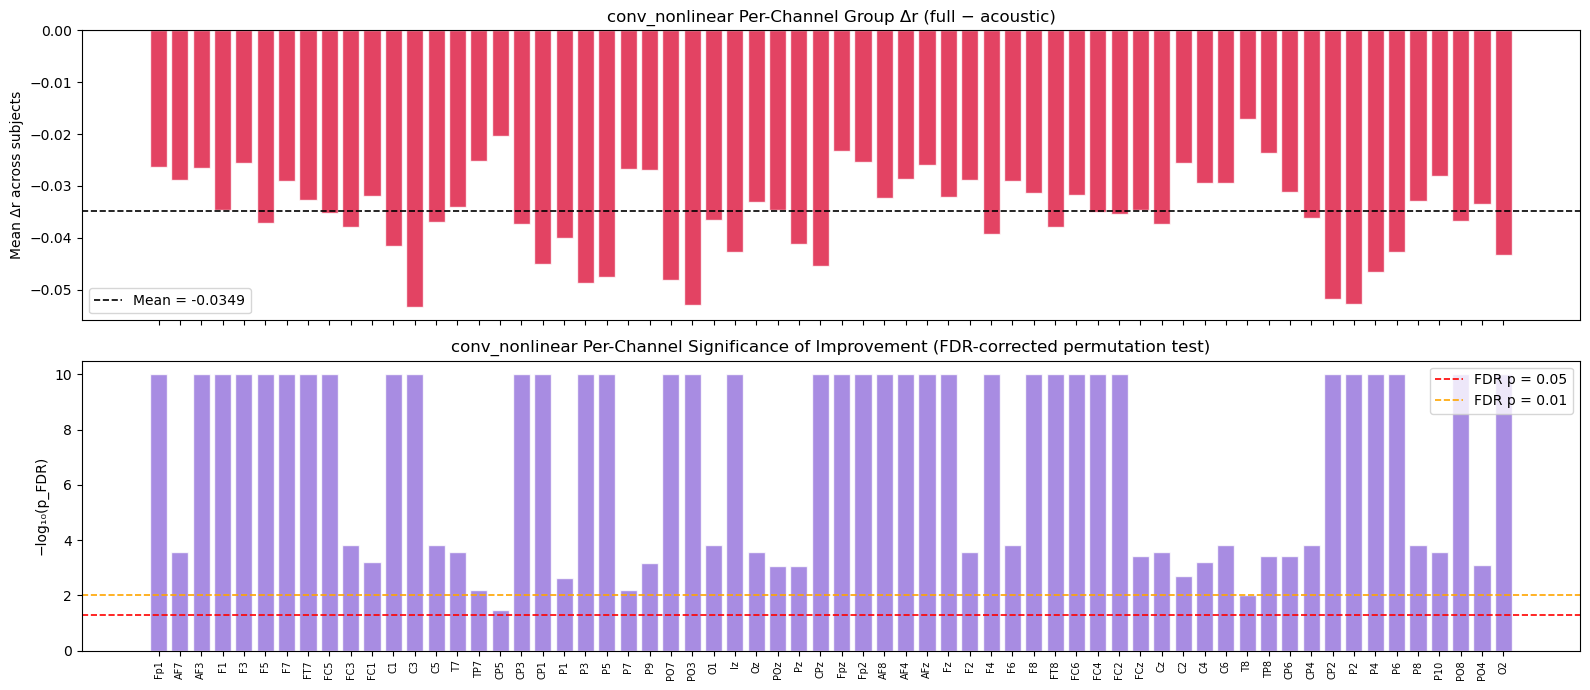

Loading conv_linear Results
  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.0064  **
  Mean Δr = 0.0015 ± 0.0005 SEM
  Channels significant after FDR (p<0.05): 24 / 64


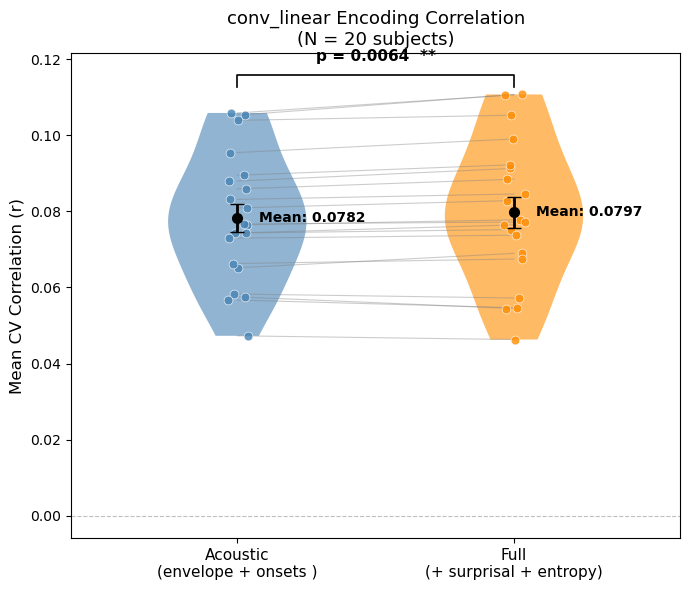

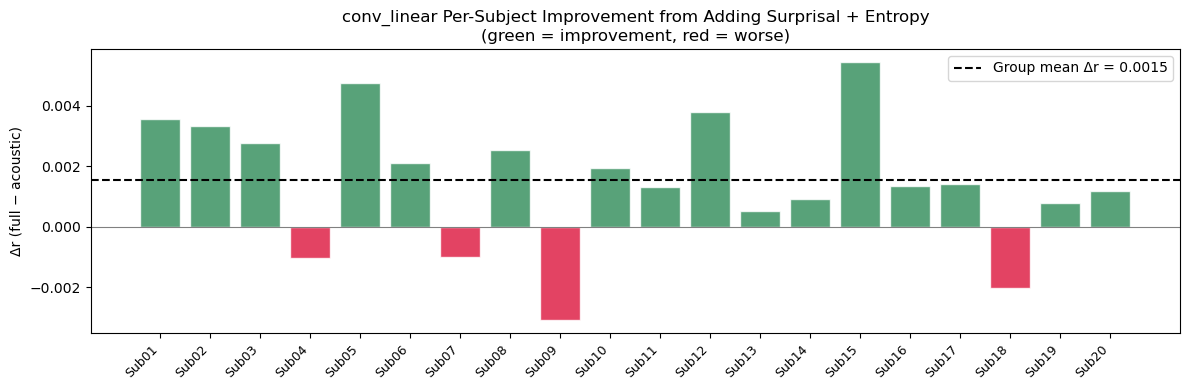

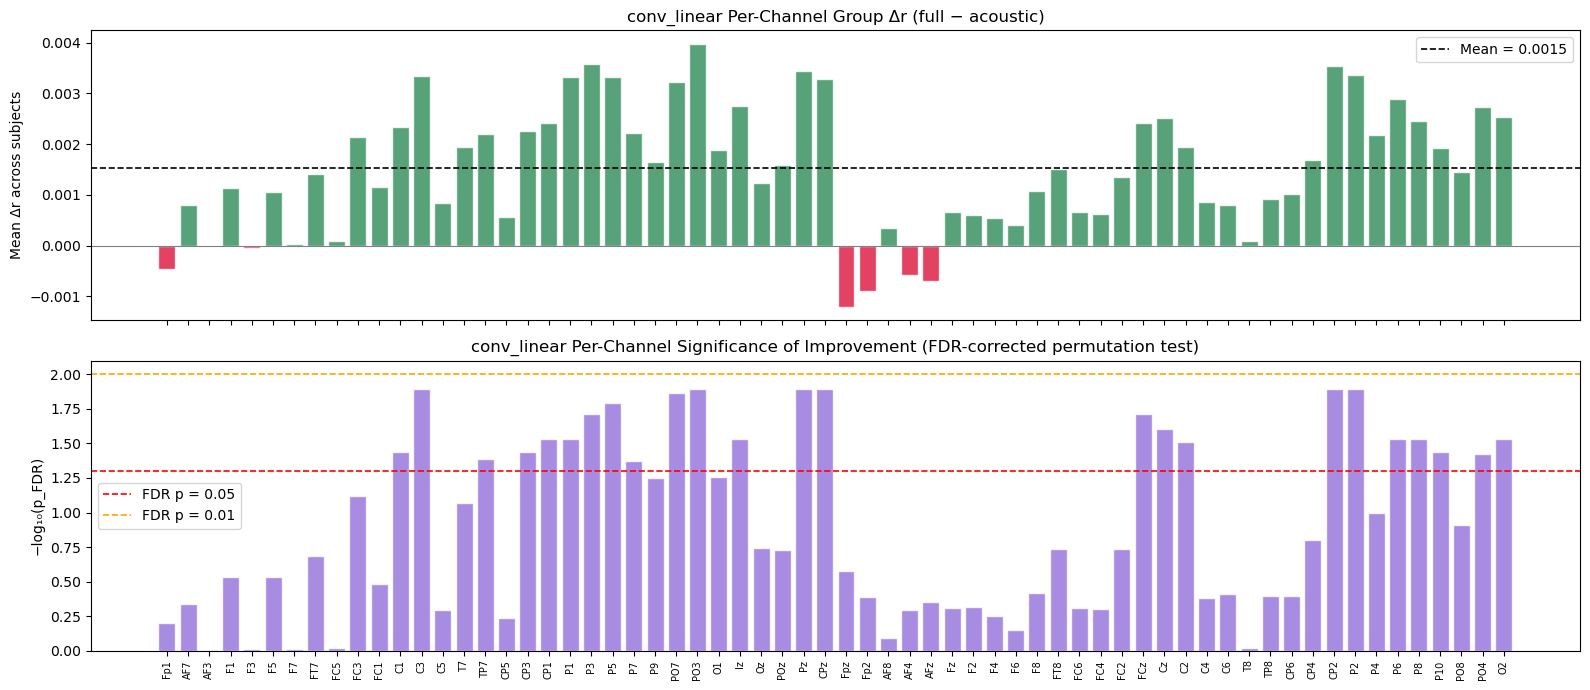

Loading conv_separable Results
  Sub01 loaded
  Sub02 loaded
  Sub03 loaded
  Sub04 loaded
  Sub05 loaded
  Sub06 loaded
  Sub07 loaded
  Sub08 loaded
  Sub09 loaded
  Sub10 loaded
  Sub11 loaded
  Sub12 loaded
  Sub13 loaded
  Sub14 loaded
  Sub15 loaded
  Sub16 loaded
  Sub17 loaded
  Sub18 loaded
  Sub19 loaded
  Sub20 loaded

Loaded 20 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 0.0000  ***
  Mean Δr = 0.0034 ± 0.0004 SEM
  Channels significant after FDR (p<0.05): 64 / 64


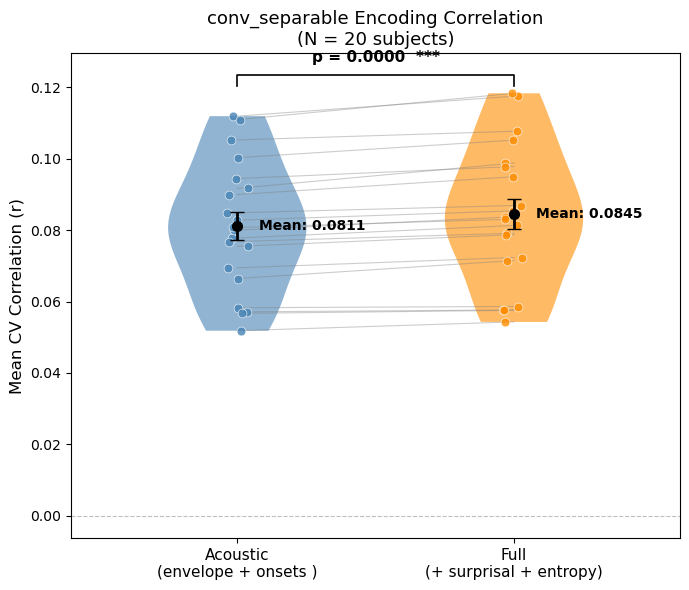

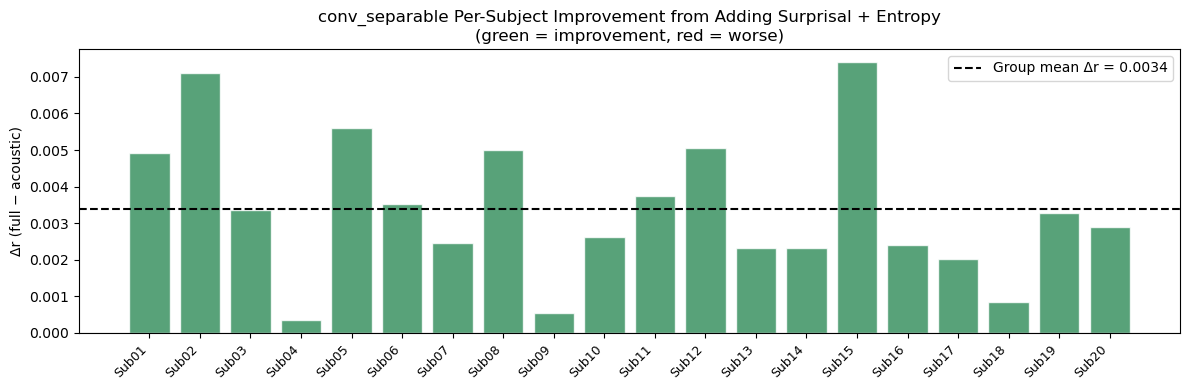

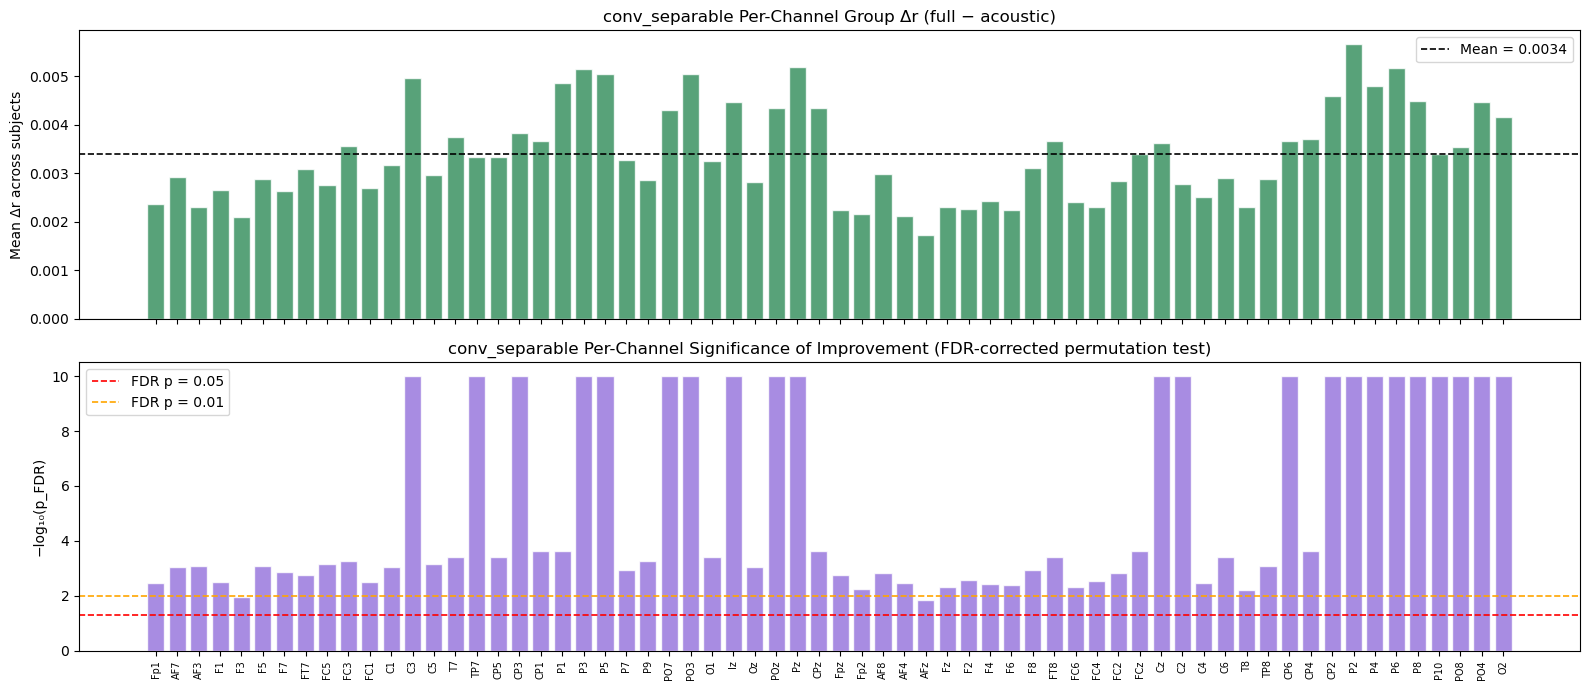

In [53]:
models = ['boosting', 'sklearn_ridge', 'mne_ridge', 'conv_nonlinear','conv_linear','conv_separable' ]

for model in models:
    plot_model_results(model)

## Next visuals:
- plot a topograph per subject, per model 
- Alignment plots of the pred and ground truth EEGs, inspecting specific channels / trials / subject combos

Training plots 

In [ ]:
def plot_topobutterfly(result, save_dir, sfreq=DEFAULT_SFREQ,
                        tmin=DEFAULT_TMIN, tmax=DEFAULT_TMAX):
    """Actual-vs-predicted ERP as an eelbrain TopoButterfly: all channels
    overlaid, plus a scalp topomap. Feeds every trial's Y_true/Y_pred to
    TopoButterfly directly (as a Case dimension) and lets it average over
    trials and pick the topomap time itself -- no manual averaging or
    peak-time computation here. tmin/tmax set the displayed window
    (xlim), matching this project's TRF receptive-field convention."""
    built = _build_case_ndvars(result, sfreq, tmin=tmin, tmax=tmax)
    if built is None:
        return
    nd_true, nd_pred, meta, model_tag = built
    subject, feature_set = meta['subject'], meta['feature_set']

    title = f'{subject}  ·  {model_tag}  ·  {feature_set}'
    p = eelbrain.plot.TopoButterfly(
        [nd_true, nd_pred], xlim=(tmin, tmax), w=10, h=4, clip='circle',
        show=False, title=title)
    fname = save_dir / f"{subject}_{feature_set}_{model_tag}_topobutterfly.png"
    # p.save(fname)
    # p.close()
    return fname


In [ ]:
def plot_topoarray(result, save_dir, sfreq=DEFAULT_SFREQ,
                    tmin=DEFAULT_TMIN, tmax=DEFAULT_TMAX):
    """Actual-vs-predicted ERP as an eelbrain TopoArray: scalp topomaps at a
    few representative times spread across the tmin/tmax window. Feeds every
    trial's Y_true/Y_pred to TopoArray directly (as a Case dimension) and
    lets it average over trials -- no manual averaging here."""
    built = _build_case_ndvars(result, sfreq, tmin=tmin, tmax=tmax)
    if built is None:
        return
    nd_true, nd_pred, meta, model_tag = built
    subject, feature_set = meta['subject'], meta['feature_set']

    times = [tmin + f * (tmax - tmin) for f in _TOPOARRAY_TIME_FRACTIONS]
    title = f'{subject}  ·  {model_tag}  ·  {feature_set}'
    p = eelbrain.plot.TopoArray(
        [nd_true, nd_pred], t=times, xlim=(tmin, tmax), w=6, h=4, clip='circle',
        show=False, title=title)
    fname = save_dir / f"{subject}_{feature_set}_{model_tag}_topoarray.png"
    # p.save(fname)
    # p.close()
    return fname


In [ ]:
def plot_alignment(result, save_dir, channel_idx=DEFAULT_CHANNEL_IDX, sfreq=DEFAULT_SFREQ):
    """Predicted-vs-actual EEG alignment plot, built entirely from a `result`
    dict (see build_result). Skipped when the result has no Y_true/Y_pred
    (the eelbrain.boosting exception, see build_result's docstring)."""
    Y_true, Y_pred = result['Y_true'], result['Y_pred']
    if Y_true is None or Y_pred is None:
        return

    meta = result['meta']
    subject, feature_set = meta['subject'], meta['feature_set']
    model_tag = meta['model_family']
    if meta.get('model_variant'):
        model_tag = f"{model_tag}_{meta['model_variant']}"

    r_vals = result['r_per_channel']
    ch = channel_idx if channel_idx < Y_true.shape[1] else 0
    n_plot = min(len(Y_true), int(10 * sfreq))
    t_plot = np.arange(n_plot) / sfreq

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.suptitle(
        f'Predicted vs Actual EEG  |  {subject}, channel {ch}\n'
        f'{model_tag}  ·  {feature_set}  ·  r = {r_vals[ch]:.3f}',
        fontsize=12, fontweight='bold')

    axes[0].plot(t_plot, Y_true[:n_plot, ch],
                 color='black', lw=0.7, label='Actual EEG (z-scored)')
    axes[0].plot(t_plot, Y_pred[:n_plot, ch],
                 color='seagreen', lw=0.9, alpha=0.85,
                 label=f'Predicted EEG  (r = {r_vals[ch]:.3f})')
    axes[0].set_ylabel('z-score')
    axes[0].set_title(f'Actual vs Predicted EEG  ({model_tag})')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t_plot, Y_true[:n_plot, ch] - Y_pred[:n_plot, ch],
                 color='darkorange', lw=0.7, label='Residual (actual - predicted)')
    axes[1].axhline(0, color='black', lw=0.6, linestyle='--')
    axes[1].set_ylabel('z-score')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_title('Residual: Actual - Predicted')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    fname = save_dir / f"{subject}_{feature_set}_{model_tag}_alignment_ch{ch}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return fname
